# ICE State Estimation Tutorial

This notebook walks through **moving-horizon state estimation (MHE)** for the torsional dynamics of a six-cylinder internal combustion engine (ICE):

1. **Build** a discrete-time state-space model from the continuous engine model.
2. **Simulate** engine data with realistic piston torques, throttle control, and noisy measurements.
3. **Estimate** the full state trajectory with moving-horizon estimation, using partial state and input measurements over a receding horizon.

The engine model is built with [OpenTorsion](https://github.com/tamasmak/opentorsion), based on the [internal combustion example](https://aalto-arotor.github.io/openTorsion/notebooks/ICE_example.html) from its documentation. The example itself is based on the article "Analysis of torsional vibration in internal combustion engines: Modelling and experimental validation" by Mendes AS, Meirelles PS, Zampieri DE, [doi:10.1243/14644193JMBD126](https://www.doi.org/10.1243/14644193JMBD126).

The engine model is outfitted with a simple directly driven propeller to model the propeller shaft torque and water load input.

**The example is designed to be an example of the basic capabilites of the moving-horizon estimation pipeline alongside OpenTorsion, and not necessarily a realistic use case. The simulated engine is quite poor, but functions well for our purposes.**

## The estimation problem

A ship's propulsion system is not rigid: combustion pulses, propeller dynamics, transmission components etc. excite **torsional vibrations** that travel along the shaft. We model this as a chain of inertias (disks) connected by torsional springs (shaft segments), giving a linear state-space system

$$\dot{x}(t) = A_c\,x(t) + B_c\,u(t), \qquad y(t) = C\,x(t) + D\,u(t),$$

where the state $x$ collects shaft torques and disk angular speeds, the input $u$ collects the six cylinder torques (calculated naively from cylinder pressure) plus the propeller (load) torque. The output y consists of those states we can *measure*, for example a couple of angular speeds, maybe at the free-end accessory pulley and the flywheel.

The goal is to reconstruct the **full internal state** (all shaft torques and speeds) and the **unmeasured load torque** from those speed and cylinder pressure sensors. Moving-horizon estimation does this by solving, at every time step, a small optimization problem over a sliding window of the most recent measurements, regularized by an *arrival cost* that compresses everything observed before the window as well as an input *trend-filtering* term.

## Roadmap

| Section | What it covers |
| --- | --- |
| Geometry & model | Engine constants, the lumped torsional model, and its state-space form |
| Piston torques | Crank-slider gas + inertia torque physics |
| Simulation | Generating noisy ground-truth data |
| Arrival cost | A Kalman filter that seeds each MHE window |
| MHE window | The per-window quadratic program |
| Run & plot | Receding-horizon loop and result comparison |

Throughout, discrete time steps are indexed by $k$, with sampling period $\Delta t$ (`dt`).


## Setup

The tutorial relies on a small scientific-Python stack:

- **`openmhe`**: python interface for creating the acados-based optimization pipeline, created at AROTOR.
- **`opentorsion`**: builds the lumped torsional driveline model and its state-space matrices, created at AROTOR.
- **`numpy`**: array math throughout.
- **`scipy`**: `cont2discrete` for discretizing the model and `pinv` for the minimal-coordinate transform.
- **`matplotlib`**: diagnostic plots.

In [29]:
from pathlib import Path
import time

import openmhe as mhe
import matplotlib.pyplot as plt
import numpy as np
import opentorsion as ot
from scipy.linalg import pinv
from scipy.signal import cont2discrete

## Engine geometry and firing

These constants describe the **crank-slider mechanism** that turns gas pressure into crank torque, plus the engine's firing pattern. They feed the piston-torque physics defined later.

| Symbol | Constant | Meaning |
| --- | --- | --- |
| $l$ | `L_ROD` | Connecting-rod length |
| $D$ | `D_PISTON` | Piston bore diameter |
| $r$ | `R_CRANK` | Crank radius (half the stroke) |
| $m_a$ | `M_A` | Reciprocating (piston + rod) mass |
| $\lambda$ | `LAMBDA_RL` | Crank-to-rod ratio $r/l$ |
| $A_p$ | `PISTON_AREA` | Piston crown area $\tfrac{\pi}{4}D^2$ |

The piston area is the usual circle area:

$$A_p = \frac{\pi}{4} D^2.$$

### Firing order and phasing

This is a four-stroke six-cylinder engine, so one full thermodynamic cycle spans **two crank revolutions** ($720^\circ = 4\pi$). With six evenly-spaced power strokes per cycle, cylinders fire $\tfrac{720^\circ}{6} = 120^\circ = \tfrac{2\pi}{3}$ apart (`PHASE_SHIFT`), following the `FIRING_ORDER` `[0, 4, 2, 5, 1, 3]`. Each cylinder therefore sees the same pressure curve but shifted in crank angle.

In [ ]:
# Engine constants
INITIAL_RPM = 1000.0
FIRING_ORDER = np.array([0, 4, 2, 5, 1, 3])
PHASE_SHIFT = 2 / 3 * np.pi

# Piston torque calculation constants
L_ROD = 0.207
D_PISTON = 0.105
R_CRANK = 0.137 / 2
M_A = 2.521
LAMBDA_RL = R_CRANK / L_ROD
PISTON_AREA = 0.25 * np.pi * D_PISTON ** 2

## The torsional driveline model

`crankshaft_assembly` builds the mechanical model in OpenTorsion as a chain of **disks** (lumped inertias $J$) joined by **shafts** (torsional springs $k$), with viscous damping $c$ on selected nodes. The eleven nodes run from the torsional vibration damper (TVD) at the front, through the six cylinder throws, to the flywheel and finally a direct-drive shaft to the propeller.

### Equations of motion

A lumped torsional system obeys the second-order ODE

$$\mathbf{J}\,\ddot{\theta} + \mathbf{C}\,\dot{\theta} + \mathbf{K}\,\theta = T(t),$$

with $\theta$ the nodal twist angles, $\mathbf{J}$ the inertia matrix, $\mathbf{K}$ the stiffness matrix assembled from the shaft constants, $\mathbf{C}$ the damping matrix, and $T$ the applied torques.

### First-order state space

OpenTorsion's `assembly.state_space()` recasts this as a first-order system

$$\dot{x} = A_c x + B_c u, \qquad y = C x + D u,$$

stacking angles and speeds. `build_model` then:

1. **Reduces to minimal coordinates** with the transform `X` (`assembly.X`): $A = X A_c X^{+}$, $B = X B_c$, where $X^{+}$ is the pseudo-inverse (`scipy.linalg.pinv`). This removes one redudant DOF and gives direct access to the torque states.
2. **Selects the physical inputs**: columns `3:9` are the six cylinder torques, and the last column is the propeller load, giving $u \in \mathbb{R}^{7}$.
3. **Defines the measurements**: $C$ picks two angular-speed states — the **pulley** speed and the **flywheel** speed — so $y \in \mathbb{R}^2$.

### State / index map

The returned `indices` dictionary names the slices used elsewhere:

| Key | Meaning |
| --- | --- |
| `flywheel` (19) | Flywheel angular-speed state |
| `propeller` (20) | Propeller angular-speed state |
| `cyl_speeds` (13:19) | The six cylinder angular speeds (used for crank-angle integration) |
| `speeds` (10:) | All angular-speed states (initialized to the starting RPM) |

In [ ]:
# OpenTorsion assembly: TVD, crankshaft, flywheel, and propeller.
def crankshaft_assembly():
    """OpenTorsion assembly: TVD, crankshaft, flywheel, and propeller."""
    J1, k1, d1 = 0.1520, 7e4, 3.0
    J2, J3 = 0.0170, 0.0090
    J4, J5, J6 = 0.0467, 0.0327, 0.0467
    J7, J8, J9 = 0.0467, 0.0327, 0.0487
    J10, J11 = 2.0750, 0.77
    k2, k3, k4 = 1.106e6, 1.631e6, 1.253e6
    k5, k6, k7 = 1.253e6, 1.678e6, 1.253e6
    k8, k9, k10 = 1.253e6, 1.976e6, 1.63e4
    c_a = 0.5

    shafts, disks = [], []
    disks.append(ot.Disk(0, J1, c=d1))
    shafts.append(ot.Shaft(0, 1, None, None, k=k1, I=0))
    disks.append(ot.Disk(1, J2))
    shafts.append(ot.Shaft(1, 2, None, None, k=k2, I=0))
    disks.append(ot.Disk(2, J3))
    shafts.append(ot.Shaft(2, 3, None, None, k=k3, I=0))
    disks.append(ot.Disk(3, J4, c=c_a))
    shafts.append(ot.Shaft(3, 4, None, None, k=k4, I=0))
    disks.append(ot.Disk(4, J5, c=c_a))
    shafts.append(ot.Shaft(4, 5, None, None, k=k5, I=0))
    disks.append(ot.Disk(5, J6, c=c_a))
    shafts.append(ot.Shaft(5, 6, None, None, k=k6, I=0))
    disks.append(ot.Disk(6, J7, c=c_a))
    shafts.append(ot.Shaft(6, 7, None, None, k=k7, I=0))
    disks.append(ot.Disk(7, J8, c=c_a))
    shafts.append(ot.Shaft(7, 8, None, None, k=k8, I=0))
    disks.append(ot.Disk(8, J9, c=c_a))
    shafts.append(ot.Shaft(8, 9, None, None, k=k9, I=0))
    disks.append(ot.Disk(9, J10))
    shafts.append(ot.Shaft(9, 10, None, None, k=k10, I=0))
    disks.append(ot.Disk(10, J11, c=2.0))

    return ot.Assembly(shafts, disk_elements=disks)

# Map OpenTorsion coordinates to minimal state-space form.
def to_minimal(matrix, assembly, kind):
    """Map OpenTorsion coordinates to minimal state-space form."""
    X = assembly.X
    if kind == "state":
        return X @ matrix @ pinv(X)
    return X @ matrix

# Build the state-space matrices for openMHE, with indices for plotting.
def build_model(assembly):
    """Return continuous-time (A, B, C, D) and useful state indices."""
    A_full, B_full, _, _ = assembly.state_space()
    B_full[:, -1] *= -1

    A = to_minimal(A_full, assembly, "state")
    B = to_minimal(B_full, assembly, "input")
    B = np.hstack([B[:, 3:9], B[:, -1:]])  # 6 piston torques + propeller load

    gear_speed = 11
    flywheel_speed = 19
    propeller_speed = 20
    cyl_speed_slice = slice(13, 19)

    C = np.eye(A.shape[0])[[gear_speed, flywheel_speed], :]
    D = np.zeros((C.shape[0], B.shape[1]))

    indices = {
        "flywheel": flywheel_speed,
        "propeller": propeller_speed,
        "cyl_speeds": cyl_speed_slice,
        "speeds": slice(10, A.shape[0]),
    }
    return A, B, C, D, indices

## Cylinder pressure and piston torque

The forcing that drives the torsional dynamics is the torque each cylinder applies to the crank. It has two parts: a **gas force** from combustion pressure and a **reciprocating inertia force** from the accelerating piston/rod mass.

### Pressure lookup

`load_pressure_tables` reads two CSVs: a normalized pressure-vs-crank-angle curve and a peak-pressure-vs-RPM scaling. `cylinder_pressure` interpolates the shape from the first table and scales it by the speed-dependent peak (clamped below 1000 rpm and above 2000 rpm), returning pressure in Pa ($\times 10^6$).

### Crank-slider kinematics

For crank angle $\alpha$ and ratio $\lambda = r/l$, the connecting-rod obliquity angle is

$$\beta = \arcsin(\lambda \sin\alpha).$$

The factor that converts an axial piston force into a tangential force on the crank pin is $\dfrac{\sin(\alpha+\beta)}{\cos\beta}$, and multiplying by the crank radius $r$ turns that force into torque.

### Gas torque

The combustion gas force on the piston crown is $F_g = p\,A_p$ (pressure times piston area). Its torque contribution is

$$T_g = r\,F_g\,\frac{\sin(\alpha+\beta)}{\cos\beta}.$$

### Inertia torque

The reciprocating mass $m_a$ produces an inertia force that, expanded as a Fourier series in $\alpha$, is approximated here by

$$F_{ia} = -\,m_a\,r\left(\cos\alpha + \lambda\cos 2\alpha - \tfrac{\lambda^3}{4}\cos 4\alpha + \tfrac{9\lambda^5}{128}\cos 6\alpha\right)\omega^2,$$

where $\omega$ is the local cylinder speed. Its torque uses the same geometric factor, so the **total piston torque** is

$$T = r\,\big(F_g + F_{ia}\big)\,\frac{\sin(\alpha+\beta)}{\cos\beta}.$$

`piston_torques` evaluates this for all six cylinders simultaneously, using their individual crank angles (offset by the firing order) and speeds.

In [ ]:
# Load the pressure tables from files.
def load_pressure_tables():
    data_dir = Path("ICE_data")
    if not data_dir.is_dir():
        data_dir = Path("jupyter_tutorial") / "ICE_data"

    pressure = np.genfromtxt(data_dir / "pressure_data.csv", delimiter=";")
    peak = np.genfromtxt(data_dir / "peak_data.csv", delimiter=";")
    return (
        pressure[:, 0],
        pressure[:, 1] / np.max(pressure[:, 1]),
        peak[:, 0],
        peak[:, 1],
    )


P_ANGLE, P_VALUES, PEAK_RPM, PEAK_SCALE = load_pressure_tables()

# Interpolate the pressure curve for a given RPM and crank angle.
def cylinder_pressure(rpm, crank_angle_deg):
    base = np.interp(crank_angle_deg, P_ANGLE, P_VALUES)
    
    # Clamp the pressure below 1000 rpm and above 2000 rpm.
    if rpm < 1000:
        scale = PEAK_SCALE[0]
    elif rpm > 2000:
        scale = PEAK_SCALE[-1]
    else:
        scale = np.interp(rpm, PEAK_RPM, PEAK_SCALE)
    return base * scale * 1e6

# Calculate piston torques for all six cylinders.
def piston_torques(x, crank_angles, indices):
    rpm = x[indices["flywheel"]] * 60.0 / (2 * np.pi)
    crank_deg = crank_angles * 180.0 / np.pi
    pressures = cylinder_pressure(rpm, crank_deg)
    w = x[indices["cyl_speeds"]]

    alpha = crank_angles
    beta = np.arcsin(LAMBDA_RL * np.sin(alpha))
    sin_ab = np.sin(alpha + beta)
    cos_b = np.cos(beta)

    f_g = pressures * PISTON_AREA
    f_tg = f_g * sin_ab / cos_b
    f_ia = (
        -M_A
        * R_CRANK
        * (
            np.cos(alpha)
            + LAMBDA_RL * np.cos(2 * alpha)
            - LAMBDA_RL**3 / 4 * np.cos(4 * alpha)
            + 9 * LAMBDA_RL**5 * np.cos(6 * alpha) / 128
        )
        * w**2
    )
    return (f_tg + f_ia * sin_ab / cos_b) * R_CRANK

# Simple quadratic propeller load.
def propeller_load(k_prop, omega):
    return np.array([-k_prop * omega**2])

## Simulating the engine

To test the estimator we need ground-truth data. `simulate_engine` integrates the model forward in discrete time and records the (hidden) full state, the noisy measurements, and the inputs.

### Discretization

The continuous system is converted to a discrete one for sampling period $\Delta t$ via `scipy.signal.cont2discrete` (zero-order hold):

$$x_{k+1} = A_d\,x_k + B_d\,u_k + w_k, \qquad y_k = C_d\,x_k + v_k.$$

### Noise

Realistic sensors and model error are emulated with zero-mean Gaussian noise:

$$w_k \sim \mathcal{N}(0,\,\sigma_w^2 I), \quad \sigma_w = 0.01 \qquad\text{(process)}$$
$$v_k \sim \mathcal{N}(0,\,\sigma_v^2 I), \quad \sigma_v = 0.5 \qquad\text{(measurement)}$$

### Inputs at each step

- **Piston torques** come from `piston_torques`, evaluated at the current crank angles.
- **Load torque** is the propeller law $T_{\text{load}} = -k_{\text{prop}}\,\omega^2$, a quadratic drag on the propeller speed.

After each step the per-cylinder crank angles are advanced by $\alpha \mathrel{+}= \omega_{\text{cyl}}\,\Delta t$ and wrapped modulo the $4\pi$ (720°) four-stroke cycle. The engine starts spinning at `INITIAL_RPM` on all speed states.

In [ ]:
def simulate_engine(A, B, C, D, indices, t_end, dt, k_prop=0.01, seed=0):
    """Forward simulate the engine with process and measurement noise."""
    rng = np.random.default_rng(seed)
    n_steps = int(np.ceil(t_end / dt))
    omega0 = INITIAL_RPM * 2 * np.pi / 60

    # Initialize the state vector.
    x = np.zeros(A.shape[0])
    x[indices["speeds"]] = omega0
    crank_angles = np.array(
        [(PHASE_SHIFT * cyl) % (4 * np.pi) for cyl in FIRING_ORDER],
        dtype=np.float64,
    )

    # Discretize the system.
    A_d, B_d, C_d, _, _ = cont2discrete((A, B, C, D), dt)

    # Generate noise.
    w_noise = rng.normal(0, 0.01, (n_steps, A.shape[0]))
    v_noise = rng.normal(0, 0.5, (n_steps, C.shape[0]))

    # Create output arrays.
    t = np.arange(n_steps) * dt
    x_hist = np.zeros((n_steps, A.shape[0]))
    y_hist = np.zeros((n_steps, C.shape[0]))
    u_hist = np.zeros((n_steps, B.shape[1]))

    # Simulate the engine through the time steps.
    for i in range(n_steps):
        u_piston = piston_torques(x, crank_angles, indices)
        u_load = propeller_load(k_prop, x[indices["propeller"]])
        u = np.concatenate([u_piston, u_load])

        x = A_d @ x + B_d @ u + w_noise[i]
        y = C_d @ x + v_noise[i]
        crank_angles = (crank_angles + x[indices["cyl_speeds"]] * dt) % (4 * np.pi)

        x_hist[i] = x
        y_hist[i] = y
        u_hist[i] = u

    print(f"Simulation finished: {n_steps} steps ({t_end:.1f} s, dt={dt:g} s)")
    return t, x_hist, y_hist, u_hist

## The moving-horizon estimator

This is the heart of the process. Over a window of $N$ recent steps (`horizon`), MHE is fed the measured states $y$ and measured inputs $u^{(6)}$. The MHE then finds the state trajectory $x_0,\dots,x_{N-1}$ and the unknown load input $u_0,\dots,u_{N-1}$ that best explain the measurements, by minimizing

$$
\begin{aligned}
& \underset{x,\, u,\, \delta}{\text{minimize}} && \underbrace{\left\lVert x_{t-N} - \hat{x}_{t-N|t-N-1} \right\rVert^2_{P_{t-N|t-N-1}^{-1}}}_{\text{EKF arrival cost}} + \underbrace{\sum_{k=t-N}^{t} \left\lVert v_{k} \right\rVert^2_{R^{-1}}}_{\text{measurement error}} + \underbrace{\sum_{k=t-N}^{t-1} \left\lVert w_{k} \right\rVert^2_{Q^{-1}}}_{\text{process noise}} + \underbrace{\sum_{k=t-N}^{t-1} \lambda\, \left\lVert \delta_{k} \right\rVert_{2}^{2}}_{\text{random walk}} \\
& \text{subject to} \\
& && x_{k} = A x_{k-1} + B u_{k-1} + w_{k}, \\
& && y_{k} = C x_{k} + D u_{k} + v_{k}, \\
& && \delta_{k} = u^{(6)}_{k} - u^{(6)}_{k-1}
\end{aligned}
$$

Simply put, every $dt$ seconds, the Moving-Horizon Estimator looks at the recent history of the engine and says: 

*"Find me the exact sequence of twisting shaft torques, internal cylinder speeds, and the unknown propeller load that (1) respects the rigid-body physics of the spinning shaft, (2) matches our physical sensor readings as closely as possible, (3) aligns with our historical knowledge of the engine prior to this window, and (4) assumes the propeller load doesn't spike erratically."*

### Objective function terms
The optimization problem consists of 4 terms:

#### **1. EKF arrival cost**
* Because our sliding window only looks at the last $N$ steps, it is "blind" to anything that happened before the window started. The arrival cost acts as a mathematical summary of all historical data from $t=0$ up to the start of the window at $t-N$.
* **The Terms:** 
  * $x_{t-N}$ is the state at the beginning of our current window.
  * $\hat{x}_{t-N|t-N-1}$ is the "prior" prediction of that state (provided by an Extended Kalman Filter, EKF, running in the background).
  * $P^{-1}$ is the inverse covariance matrix. It acts as a confidence weight. If the EKF is highly confident in its prior prediction (small variance $P$), $P^{-1}$ is large, which heavily penalizes the MHE if it tries to stray too far from the EKF's prediction.

#### **2. Measurement Error**
* This penalizes the difference between what your mathematical engine model *thinks* the sensors should be reading, and what the physical sensors are *actually* reading.
* **The Terms:**
  * $v_k$ is the measurement residual (the error).
  * $R^{-1}$ is the inverse of the sensor noise covariance. If you have a highly accurate, expensive optical encoder measuring flywheel speed, its $R$ value is very small, meaning $R^{-1}$ is massive. The optimizer will prioritize forcing the model to perfectly match that specific sensor over a cheaper, noisier sensor.

#### **3. Process Noise**
* This penalizes how much the estimator is forced to "cheat" the laws of physics defined in your state-space model to make the math align with the sensor data. 
* **The Terms:**
  * $w_k$ represents unmodeled disturbances or structural model inaccuracies. 
  * $Q^{-1}$ is the inverse process noise covariance. No 6-cylinder engine model is perfect—there are tiny torsional flexes and varying friction coefficients that are too complex to model. By allowing a small amount of $w_k$, the estimator has the flexibility to correct for these real-world imperfections without completely breaking the simulation.

#### **4. Random Walk (Input Regularization)**
* A smoothing penalty specifically targeted at the *unmeasured* input (the water load on the propeller). The MHE is trying to guess the propeller load. Because the engine speed sensors are noisy, an unconstrained optimizer might guess that the propeller load is oscillating wildly in order to perfectly fit the noisy sensor data. The random walk term enforces a physical reality: hydrodynamic propeller load changes relatively smoothly. It penalizes erratic, high-frequency spikes in the estimated load.
* **The Terms:**
  * $\delta_k$ is the change in the unknown input from one time step to the next.
  * $\lambda$ is a tuning weight.

### Constraints
In this constrained equation form, the system dynamics are outlined in the "subject to" block. These dynamics constrain the selection of the optimized values:

#### **1. State Equation (The Engine's Physics)**
$$x_{k} = A x_{k-1} + B u_{k-1} + w_{k}$$
* $x$ represents the internal "state" vector (the angular speeds of the 6 cylinders and the flywheel, plus the twisting torques on the shaft segments connecting them).
* $A$ is the state-transition matrix. It defines how inertias and torsional springs naturally interact (e.g., how a twisted shaft segment will attempt to spring back to neutral, oscillating into the next disk).
* $B$ dictates how the inputs $u$ (the 6 combustion piston torques and the propeller load) inject external energy into the shaft.
* $w_k$ is the process noise allowance from the objective function.

#### **2. Measurement Equation (The Sensors)**
$$y_{k} = C x_{k} + D u_{k} + v_{k}$$
* $y_k$ represents the actual readings from your physical sensors.
* $C$ is the observation matrix. The internal state $x$ might track 14 different variables (7 speeds, 7 shaft torques), but you might only have 2 physical sensors. Matrix $C$ strips away the unmeasured states so you can compare the model directly to the 2 sensor readings.
* $v_k$ is the sensor noise from the objective function.

#### **3. Unknown Input Definition**
$$\delta_{k} = u^{(6)}_{k} - u^{(6)}_{k-1}$$
* This simply provides the formal definition of the rate of change of the 6th input (the propeller load) so it can be penalized by the random walk term in the objective function.

In [ ]:
def run_estimation(
    dt,
    t,
    measurement_data,
    u_sim,
    A,
    B,
    C,
    D,
    horizon,
    w_cov=0.065,
    v_cov=np.diag([0.45, 0.55]),
    lambda_u=0.01,
):
    """Run sliding-window MHE with the C solver on the reduced ICE model."""

    # openmhe expects (channels, samples); simulation stores (samples, channels).
    y = np.asarray(measurement_data, dtype=float).T
    u = np.asarray(u_sim, dtype=float).T

    # Build the state-space model.
    mhe_system = mhe.SystemModel.from_matrices(
        A, B, C, D, is_discrete=False, dt=dt
    )

    n_window = horizon
    ny, nx = mhe_system.ny, mhe_system.nx

    # Create an empty objective function.
    mhe_objective = mhe.ObjectiveBuilder()

    # Add the measurement term.
    mhe_objective.add(
        mhe.MeasurementTerm(
            penalty=mhe.L2Penalty(), # Linear least squares penalty.
            weight=mhe.NoiseWeight(dim=ny, cov=v_cov), # Weight the measurements by the sensor noise covariance.
        )
    )

    # Add the process noise term.
    mhe_objective.add(
        mhe.ProcessTerm(
            penalty=mhe.L2Penalty(), # Linear least squares penalty.
            weight=mhe.NoiseWeight(dim=nx, cov=w_cov), # Weight the process noise by the process noise covariance.
        )
    )

    # Add the input random walk term.
    mhe_objective.add(
        mhe.InputRandomWalk(target_idx=[6], lambda_u=lambda_u),
    )

    # Set piston torques as known inputs with no error.
    mhe_objective.add(mhe.KnownInput([0,1,2,3,4,5]))

    # Add the EKF arrival cost.
    mhe_objective.add(mhe.EKFArrivalCost(mhe_system, builder=mhe_objective))

    # Compile the C solver.
    print("Compiling ACADOS solver...")
    solver = mhe.build_mhe_solver(
        mhe_system,
        n_window,
        mhe_objective,
        dt=dt,
        already_discrete=True,
    )

    # Run the C solver.
    print("\nRunning MHE (C solver, -O3 -march=native -ffast-math)...")
    t_mhe_start = time.perf_counter()
    u_hat, x_hat = mhe.run_c_solver(solver, y, u)
    t_mhe_elapsed = time.perf_counter() - t_mhe_start
    print(f"MHE solver time (C): {t_mhe_elapsed:.3f} s")

    n_est = u_hat.shape[1]
    est_idx = np.arange(n_window - 1, n_window - 1 + n_est)
    return t[est_idx], est_idx, x_hat.T, u_hat.T

## Visualization helpers

A set of plotting utilities for inspecting each stage. These produce figures only; the numerical work happens in the cells above.

In [40]:
def plot_assembly(assembly):
    ot.Plots(assembly).plot_assembly()


def plot_pressure_curves():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(P_ANGLE, P_VALUES)
    axes[0].set(xlabel="Crank angle [deg]", ylabel="Normalized cylinder pressure [-]",
                title="Cylinder pressure vs crank angle")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(PEAK_RPM, PEAK_SCALE, "o-")
    axes[1].set(xlabel="Engine speed [rpm]", ylabel="Peak pressure scale [bar]",
                title="Peak pressure scale vs RPM")
    axes[1].grid(True, alpha=0.3)

    fig.tight_layout()
    return fig


def plot_simulation(t, x, u):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    axes[0, 0].plot(t, u[:, 0])
    axes[0, 0].set(xlabel="t [s]", ylabel="Torque [Nm]", title="Piston 1 Input Torque")
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(t, -u[:, -1])
    axes[0, 1].set(xlabel="t [s]", ylabel="Torque [Nm]", title="Propeller Load Torque")
    axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].plot(t, x[:, 9])
    axes[1, 0].set(xlabel="t [s]", ylabel="Torque [Nm]", title="Prop Shaft Torque")
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].plot(t, x[:, -1])
    axes[1, 1].set(xlabel="t [s]", ylabel="Angular Speed [rad/s]", title="Prop Angular Speed")
    axes[1, 1].grid(True, alpha=0.3)

    fig.tight_layout()
    return fig


def plot_estimation(time_est, x, xhat, u, uhat, est_idx, zoom=(1.5, 1.8)):
    fig, axes = plt.subplots(4, 2, figsize=(14, 13))

    zoom_start, zoom_end = zoom
    time_zoom = (time_est >= zoom_start) & (time_est <= zoom_end)
    u_load_sim = u[est_idx, -1]
    u_load_est = uhat[:, -1]

    ax_torque = axes[0, 0]
    for i in range(6):
        ax_torque.plot(time_est, u[est_idx, i], label=f"Piston {i + 1}")
    ax_torque.set(ylabel="Torque [Nm]", xlabel="Time [s]", title="Piston Input Torques")
    ax_torque.legend(loc="upper right", fontsize=8)
    ax_torque.grid(True, alpha=0.3)

    axes[1, 0].plot(time_est, x[est_idx, 3], label="Simulated")
    axes[1, 0].plot(time_est, xhat[:, 3], label="Estimated")
    axes[1, 0].set(xlabel="Time [s]", ylabel="Torque [Nm]", title="Crankshaft Torsion at Cylinder 1")
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    axes[2, 0].plot(time_est, x[est_idx, 9], label="Simulated")
    axes[2, 0].plot(time_est, xhat[:, 9], label="Estimated")
    axes[2, 0].set(xlabel="Time [s]", ylabel="Torque [Nm]", title="Prop Shaft Torsion")
    axes[2, 0].legend()
    axes[2, 0].set_ylim(-1200, 1200)
    axes[2, 0].grid(True, alpha=0.3)

    axes[3, 0].plot(time_est, u_load_sim, label="Simulated")
    axes[3, 0].plot(time_est, u_load_est, label="Estimated")
    axes[3, 0].set(xlabel="Time [s]", ylabel="Torque [Nm]", title="Load Input Torque")
    axes[3, 0].legend()
    axes[3, 0].set_ylim(-500, 0)
    axes[3, 0].grid(True, alpha=0.3)

    ax_torque_zoom = axes[0, 1]
    for i in range(6):
        ax_torque_zoom.plot(
            time_est[time_zoom], u[est_idx, i][time_zoom], label=f"Piston {i + 1}"
        )
    ax_torque_zoom.set(ylabel="Torque [Nm]", xlabel="Time [s]", title="Piston Input Torques (zoom)")
    ax_torque_zoom.set_xlim(zoom_start, zoom_end)
    ax_torque_zoom.legend(loc="upper right", fontsize=8)
    ax_torque_zoom.grid(True, alpha=0.3)

    axes[1, 1].plot(time_est[time_zoom], x[est_idx, 3][time_zoom], label="Simulated")
    axes[1, 1].plot(time_est[time_zoom], xhat[time_zoom, 3], label="Estimated")
    axes[1, 1].set(xlabel="Time [s]", ylabel="Torque [Nm]", title="Crankshaft Torsion at Cylinder 1 (zoom)")
    axes[1, 1].set_xlim(zoom_start, zoom_end)
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    axes[2, 1].plot(time_est[time_zoom], x[est_idx, 9][time_zoom], label="Simulated")
    axes[2, 1].plot(time_est[time_zoom], xhat[time_zoom, 9], label="Estimated")
    axes[2, 1].set(xlabel="Time [s]", ylabel="Torque [Nm]", title="Prop Shaft Torsion (zoom)")
    axes[2, 1].set_xlim(zoom_start, zoom_end)
    axes[2, 1].legend()
    axes[2, 1].grid(True, alpha=0.3)

    axes[3, 1].plot(time_est[time_zoom], u_load_sim[time_zoom], label="Simulated")
    axes[3, 1].plot(time_est[time_zoom], u_load_est[time_zoom], label="Estimated")
    axes[3, 1].set(xlabel="Time [s]", ylabel="Torque [Nm]", title="Load Input Torque (zoom)")
    axes[3, 1].set_xlim(zoom_start, zoom_end)
    axes[3, 1].legend()
    axes[3, 1].grid(True, alpha=0.3)

    fig.tight_layout()
    return fig

## Putting it all together

Running the full pipeline end to end:

1. **Build** the crankshaft assembly and inspect it (`crankshaft_assembly`, `plot_assembly`, `plot_pressure_curves`).
2. **Model**: extract the continuous state-space matrices (`build_model`).
3. **Simulate** 5 s of noisy engine data at $\Delta t = 1\,\text{ms}$ (`simulate_engine`).
4. **Estimate** the hidden states and load torque with MHE (`run_estimation`).
5. **Compare** the estimates against ground truth (`plot_estimation`).

### Tuning knobs

The estimator's behaviour is governed by a few hyperparameters:

| Symbol | Code | Role |
| --- | --- | --- |
| $N$ | `horizon` | Window length; longer windows trade latency/compute for better performance. |
| $Q_w$ | `Q_w` | Process-noise covariance; how much we trust the dynamics model. |
| $Q_v$ | `Q_v` | Measurement-noise covariance; how much we trust the sensors. |
| $\lambda_u$ | `lambda_u` | Input-smoothness weight on the estimated load torque. |
| $\Delta t$ | `dt` | Sampling period (must match simulation and discretization). |

Smaller $Q_w$ (relative to $Q_v$) makes the estimate hug the model; smaller $Q_v$ makes it chase the measurements. $\lambda_u$ keeps the reconstructed load torque physically smooth. Note that the covariance values are set differently from the simulation. This is done to prevent over-fitting to the simulation model.

Assembly plot from OpenTorsion:


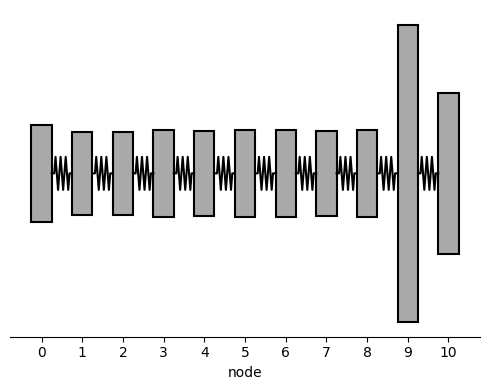

Pressure curves plot:


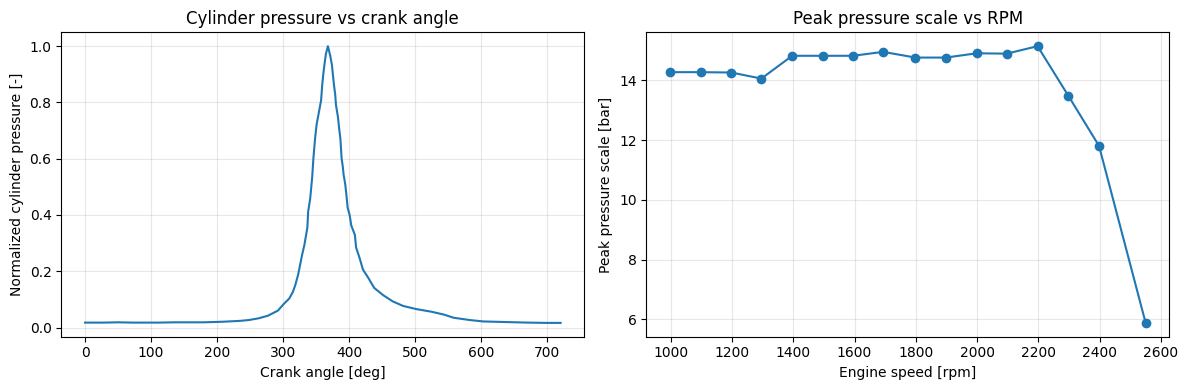

Simulation finished: 5000 steps (5.0 s, dt=0.001 s)


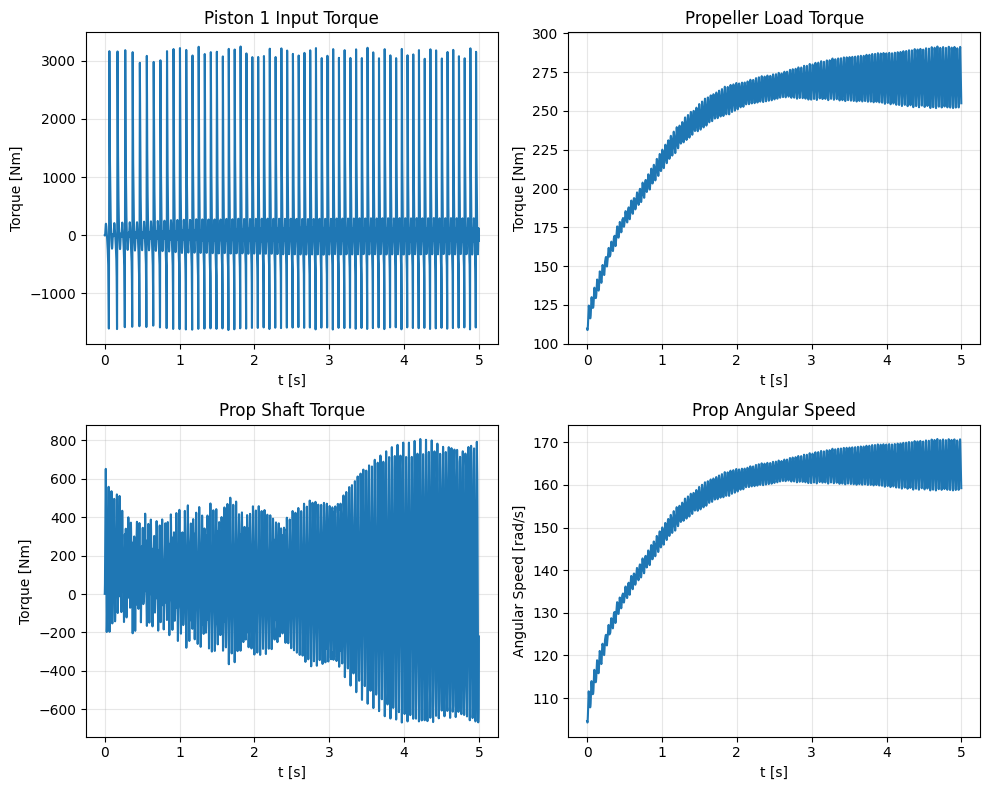

Compiling ACADOS solver...
rm -f libacados_ocp_solver_openmhe_mhe.so
rm -f acados_solver_openmhe_mhe.o
cc -fPIC -std=c99   -O2 -I/home/aksel/Code/acados/include -I/home/aksel/Code/acados/include/acados -I/home/aksel/Code/acados/include/blasfeo/include -I/home/aksel/Code/acados/include/hpipm/include  -c -o acados_solver_openmhe_mhe.o acados_solver_openmhe_mhe.c
cc -fPIC -std=c99   -O2 -I/home/aksel/Code/acados/include -I/home/aksel/Code/acados/include/acados -I/home/aksel/Code/acados/include/blasfeo/include -I/home/aksel/Code/acados/include/hpipm/include  -c -o openmhe_mhe_model/openmhe_mhe_dyn_disc_phi_fun.o openmhe_mhe_model/openmhe_mhe_dyn_disc_phi_fun.c
cc -fPIC -std=c99   -O2 -I/home/aksel/Code/acados/include -I/home/aksel/Code/acados/include/acados -I/home/aksel/Code/acados/include/blasfeo/include -I/home/aksel/Code/acados/include/hpipm/include  -c -o openmhe_mhe_model/openmhe_mhe_dyn_disc_phi_fun_jac.o openmhe_mhe_model/openmhe_mhe_dyn_disc_phi_fun_jac.c
cc -shared acados_solver_

In [ ]:
# Create the assembly and load data.
assembly = crankshaft_assembly()
print("Assembly plot from OpenTorsion:")
plot_assembly(assembly)
plot_pressure_curves()
print("Pressure curves plot:")
plt.show()

# Build and simulate the engine.
A, B, C, D, indices = build_model(assembly)

t, x, y, u = simulate_engine(A, B, C, D, indices, t_end=5.0, dt=0.001)
plot_simulation(t, x, u)
plt.show()

# Run the estimation.
horizon = 30
Q_w = 0.065
Q_v = np.diag([0.45, 0.55])
lambda_u = 1

time_est, est_idx, xhat, uhat = run_estimation(
    dt=0.001,
    t=t,
    measurement_data=y,
    u_sim=u,
    A=A,
    B=B,
    C=C,
    D=D,
    horizon=horizon,
    w_cov=Q_w,
    v_cov=Q_v,
    lambda_u=lambda_u,
)

Estimation result:


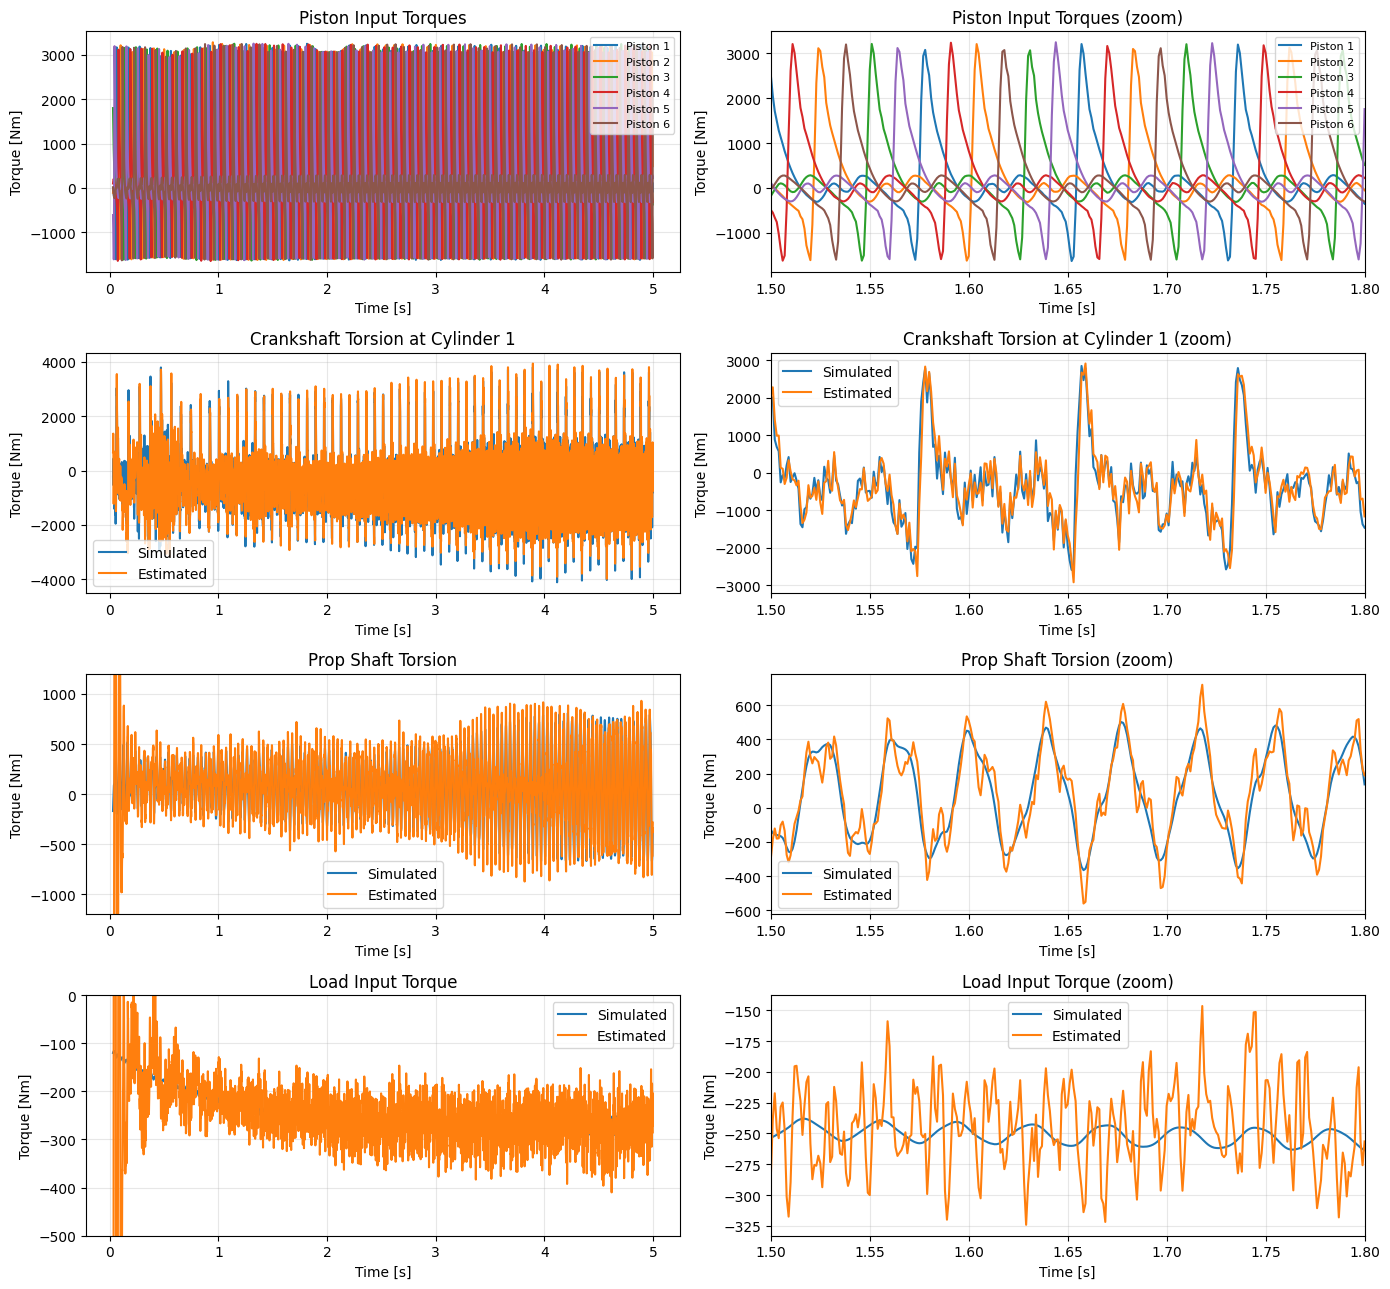

In [41]:
plot_estimation(time_est, x, xhat, u, uhat, est_idx)
print("Estimation result:")
plt.show()

## Results analysis

The process gives good results for the shaftline states, such as angular velocities and intermediate torques. Some notes however:

### Why the load is poorly observable

The load torque enters the system only at the propeller, at the very end of the shaftline, while the measurements are two angular speeds taken elsewhere on the shaft. The load therefore acts on the sensors through the compliance and inertia of the intervening shaft segment and is only measured indirectly through the angular velocity measuremet. The shaftline torque states can be calculated from the measured piston torques instead. The model seems to account for modeling and measurement errors primarily by varying the load input.

However, a poor result on the load does not make the estimator itself bad. The shaft torque is measured well, which has the primary goal. 

### Practicalities

A few points matter when moving this from a notebook toward a real application:

- **System modeling.** In real uses, the system and state space model are not an exact match. In our case we know the parameters exactly, leading to a great estimate. The MHE requires a good knowledge of system parameters for optimal performance.
- **Edge effects.** The first and last `horizon` samples are estimated with a partial window and should be treated as less reliable; note the artefact in the load estimate near the start of the run. This is not applicable for situations where estimation is continous.
- **Tuning.** The covariances `Q_w`, `Q_v` and the weight `lambda_u` encode how much you trust the model, the sensors, and the smoothness of the load. They are the primary knobs for balancing responsiveness against noise rejection.
- **Real-time use.** Each step solves a small quadratic program, and warm-starting from the previous window keeps the iteration count low, so the method is well suited to running online as data arrives.
- **Check the sampling rate against the firing harmonics.** The piston fires at the crankshaft frequency and produces harmonics at integer multiples of it. At 2000 rpm the sixth-order harmonic sits at 200 Hz, so 1 ms sampling (1 kHz) comfortably covers it. If the sampling rate were reduced for cost reasons it is worth verifying that the highest significant harmonic still falls below the Nyquist limit, otherwise those torque oscillations will be aliased into the estimate.

### Modeling improvements

Stepping forward from this simpler example, some additions/changes could be made:

- **Direct estimation from pressures.** Instead of first naively calculating the piston torque from the pressure, the pressures could be directly plugged into the state space model, so that the noise and error could be set directly.
- **Input error.** In addition to that, an error term `Q_u` could be added to weigh the measurement noise of the input pressure measurement, in addition to the state measurement error `Q_v`.
- **Update the model as the engine speeds up.** The state-space matrices are currently computed once at a fixed operating point. In reality the reciprocating-inertia forces scale with the square of engine speed, and torsional resonances shift as the speed changes. Recalculating (or interpolating) the model at each operating speed is a straightforward way to keep the dynamics accurate across the full RPM range — the plots already show the oscillation amplitude growing as the engine accelerates, which is a sign the fixed-point model is stretching its validity.
- **Secondary refining pass.** To improve the system's result, a secondary pass could be done over the estimation result. This could be done with a Kalman filter or PI observer, for example. The second estimation might reduce noise and improve accuracy further, especially for the load input estimate.